# Introduction


**File:** Notebook_BVP_k_M_structure.ipynb 
\
**Author:** Elizabeth Gould
\
**Date:** 15.03.2026
\
**Problem:** Find $k_{\mu}\left(B, R, dk, \mu\right)$ and $M_{\mu}\left(B, R, dk, \mu\right)$

This Jupyter notebook is used for modeling the changes in our wavenumbers $k_j$ and $M_j$ of the two oscillations of the solution of the nonlinear Schrödinger equation for persistant current in micrometer scale gold loops which solve the BVP requiring continuity of the wavefunction at the beginning and end of the loop. 

For our observed approximate solution to the nonlinear Schrödinger equation
\begin{equation}
\psi_j(x) = e^{i M_{j} x} \left( a_j e^{i k_{j} x} + b_j e^{- i k_{j} x} \right),
\end{equation}
we know that $\psi_j(0) = \psi_j(2\pi R_j)$ when 
\begin{equation}
\psi_j^\prime(0) = i M_{j} + k_j \left( \frac{e^{- 2 i M_{j}\pi R} - \cos\left( 2\pi k_{j} R_j \right)}{\sin\left(2\pi k_{j} R_j\right)}\right),
\end{equation}

where $k_{j}\left(\mu, R_j, B, k_0, \psi_j^\prime(0) \right)$ and $M_{j}\left(\mu, R_j, B, k_0, \psi_j^\prime(0) \right)$ are given by our previously solved model. Since the equations for $k_j$ and $M_j$ of our model are dependent on $\psi_j^\prime(0)$, we have obtained the values of $\psi_j^\prime(0)$ which solve this BVP equation with a numerical root finding algorithm. We now wish to reexamine our modeling for $k_j$ and $M_j$, and figure out the structure of the changes of $k_{j}\left(\mu, R_j, B, k_0 \right)$ and $M_{j}\left(\mu, R_j, B, k_0\right)$ from their linear solutions for the cases where $k_j$ and $M_j$ solve the BVP.

In our calculations, we vary $R_j$, $B$, $dk$, and $\mu$, with $k_0$ given by $k_0 = k_{Fermi, Au} + \frac{dk}{2 R_{max}}$.

# Loading Grid

To start with, we need to load our data into memory.

As typical, we start by loading our libraries.

In [1]:
#--LIBRARIES--------

import eelib
from eelib import pi, B_max, phi0inv, R_max
from eelib import find_ind_var, clean_table

import numpy as np
import pickle
import pandas as pd
from sklearn.linear_model import LinearRegression
import warnings

#plotting
import matplotlib.pyplot as plt
import seaborn as sns

For this notebook, we will make a list of our grid objects.

In [2]:
gridl=[]

And load each of our grids into the object, in order.

In [ ]:
# loading script; be careful of python version
file = open('grid040', 'rb')    
gridl.append(pickle.load(file))
file.close()

In [4]:
for ob in gridl: print(ob)

Grid object to measure current:
mu is: 1.5e-08
dk is: 0.45
B has 20 points from 0.5 to 0.6.
R has 511 points from 0.5709233333333332 to 0.9959233333333333.
A is: [1.]
k0 is: 12000000000.0
Total number of parameters: 10220


I want to transfer all of my data to pandas dataframes for analysis.

In [5]:
tbl = []

In [6]:
for grid in gridl:
    tbl.append(pd.DataFrame(grid.derivs))

In [7]:
del gridl # To clear up some memory. We have all the data already stored in the tables.

In [8]:
tbl[0].head() # And check a grid.

,R,B,dk,mu,k,A,dpsi0,Exact End,a0,b0,...,I0,dpsi,New End,a,b,A max new,I v1,I v2,I v3,effective mu
0,0.570923,0.5,0.45,1.500000e-08,1.200000e+10,1.0,-1.280400e+10+7.886146e+ 09j,1.0-0.0j,0.828466+0.533490j,0.171534-0.533490j,...,0.656932,-1.069520e+11-1.242407e+ 11j,0.999229+0.000005j,-4.676717+4.456248j,5.676717-4.456248j,13.676736,-10.310198,-10.353434,-10.353434- 0.000000j,2.805797e-06
1,0.570923,0.5,0.45,1.500000e-08,1.200000e+10,1.0,-1.280400e+10+7.886146e+ 09j,1.0-0.0j,0.828466+0.533490j,0.171534-0.533490j,...,0.656932,4.875075e+10-1.606264e+ 10j,1.000000-0.000000j,-0.169381-2.031243j,1.169381+2.031243j,4.382094,-1.338724,-1.338763,-1.338763- 0.000000j,2.880412e-07
2,0.570923,0.5,0.45,1.500000e-08,1.200000e+10,1.0,-1.280400e+10+7.886146e+ 09j,1.0-0.0j,0.828466+0.533490j,0.171534-0.533490j,...,0.656932,-9.530316e+10+5.021504e+ 10j,1.000000-0.000000j,2.592137+3.970891j,-1.592137-3.970891j,9.020247,4.183367,4.184274,4.184274+ 0.000000j,1.220473e-06
3,0.570923,0.5,0.45,1.500000e-08,1.200000e+10,1.0,-1.280400e+10+7.886146e+ 09j,1.0-0.0j,0.828466+0.533490j,0.171534-0.533490j,...,0.656932,1.067689e+11-2.912140e+ 10j,1.000000-0.000000j,-0.713486-4.448621j,1.713486+4.448621j,9.272680,-2.426625,-2.426973,-2.426973- 0.000000j,1.289739e-06
4,0.570923,0.5,0.45,1.500000e-08,1.200000e+10,1.0,-1.280400e+10+7.886146e+ 09j,1.0-0.0j,0.828466+0.533490j,0.171534-0.533490j,...,0.656932,4.212775e+10+7.335505e+ 10j,1.000000+0.000000j,3.556286-1.755290j,-2.556286+1.755290j,7.066790,6.109374,6.112571,6.112571+ 0.000000j,7.490928e-07


# Defining variables for analysis

I have all my data in table form, but I know that it was all produced from grids of values. I therefore want to load my potential parameter values into arrays, so that I can more easily select all data of a given value of a given parameter.

In [9]:
R_g = []
B_g = []
dk_g = []
mu_g = []

In [10]:
for df in tbl:
    R_g.append(df["R"].unique())
    B_g.append(df["B"].unique())
    dk_g.append(df["dk"].unique())
    mu_g.append(df["mu"].unique())

In [11]:
k0   = tbl[0]["k"].unique()[0]
A    = tbl[0]["A"].unique()[0]

In [12]:
gs_r1 = R_g[0].shape[0]
gs_b1 = B_g[0].shape[0]

Ok, I saved my array sizes. Now I want to check how well I have found a solution to the BVP. My tolerance here is 1 %, so all of the nonlinear solutions should give an error of around 1 %.

In [13]:
for df in tbl:
    print("Max error in new endpoint:", np.max(np.abs(df["New End"].to_numpy()-(1.0+0.0j))))
    print("Max error in old endpoint:", np.max(np.abs(df["Exact End"].to_numpy()-(1.0+0.0j))))

Max error in new endpoint: 0.00993129066726653
Max error in old endpoint: 2.6063175770843754e-11


Now lets clean the tables of excess data.

In [14]:
tbl_red = []
for df in tbl:
    tbl_red.append(df[["R", "B", "dk", "mu", 'dpsi0', 'a0', 'b0', 'A max 0', 'I0', 'dpsi', 'a', 'b', 'A max new', 'I v3', 'effective mu']])

In [15]:
tbl_cl = []

for df in tbl_red:
    tbl_cl.append(clean_table(df))

I need to check the length of my tables, as I have probably lost some solutions, and this could cause problems with the rest of my code, which may not know how to handle this.

In [16]:
for df in tbl_cl:
    print(df.shape)

(10220, 15)


Nope. All good. Fitting with multiple algorithms and starting points works well. Lets check for erroneous points on the graphs however.

Now I want to calculate my $k_j$ and $M_j$ values, using my model and my known initial derivatives of $\psi$. The difference between the linear and nonlinear solutions will be added to all of the tables.

In [17]:
del tbl_red # Clear old data.
tbl_red = [] # Reset our variable to an empty list.

In [18]:
# We are creating arrays in which to store our predicted nonlinear wave numbers.
kn = []
Mn = []
for i, df in enumerate(tbl_cl):
    kn.append(np.zeros(df.shape[0]))
    Mn.append(np.zeros(df.shape[0]))

In [19]:
# For each row in each of our tables, I am adding a model prediction for 
# both of our wave numbers. I then want to subtract the linear 
# expectation for that wave number, and add a column to our table with the 
# difference between linear and nonlinear wave number.
for i, df in enumerate(tbl_cl):
    for iel in range(df.shape[0]):
        rr = df["R"].iloc[iel]
        bb = df["B"].iloc[iel]
        kk = df["dk"].iloc[iel]
        mm = df["mu"].iloc[iel]
        
        RR = rr * R_max
        BB = bb * B_max
        
        dpsi = df['dpsi'].iloc[iel]

        k_new = eelib.pred_fast_k_true(dpsi, mm, kk, BB, RR, A=A, k0=k0)        
        M_new = eelib.pred_slow_k_v3(dpsi, mm, kk, BB, RR, A=A, k0=k0)

        dk_new = k_new - (k0+kk/1e-6/2.0)
        dM_new = M_new - rr*R_max*bb*B_max*phi0inv

        kn[i][iel] = dk_new
        Mn[i][iel] = dM_new

    tbl_cl[i]["dkn"] = kn[i]
    tbl_cl[i]["dMn"] = Mn[i]

In [20]:
# This determines which of our table columns we wish to save.
cols = []
for i, df in enumerate(tbl_cl):
    col_names = find_ind_var(i, R_g, B_g, dk_g, mu_g) # To determine which parameters to plot.
    col_names.append("dkn") # Also plot the change in fast oscillation wave number.
    col_names.append("dMn") # Also plot the change in slow oscillation wave number.
    cols.append(col_names)

In [21]:
# Our reduced tables will have only the columns which are useful for our analysis.
for i,df in enumerate(tbl_cl):
    tbl_red.append(df[cols[i]])

Ok, now that we have cleaned up datasets, lets move on to visualization, and try to figure out with what we are dealing.

# Visualization

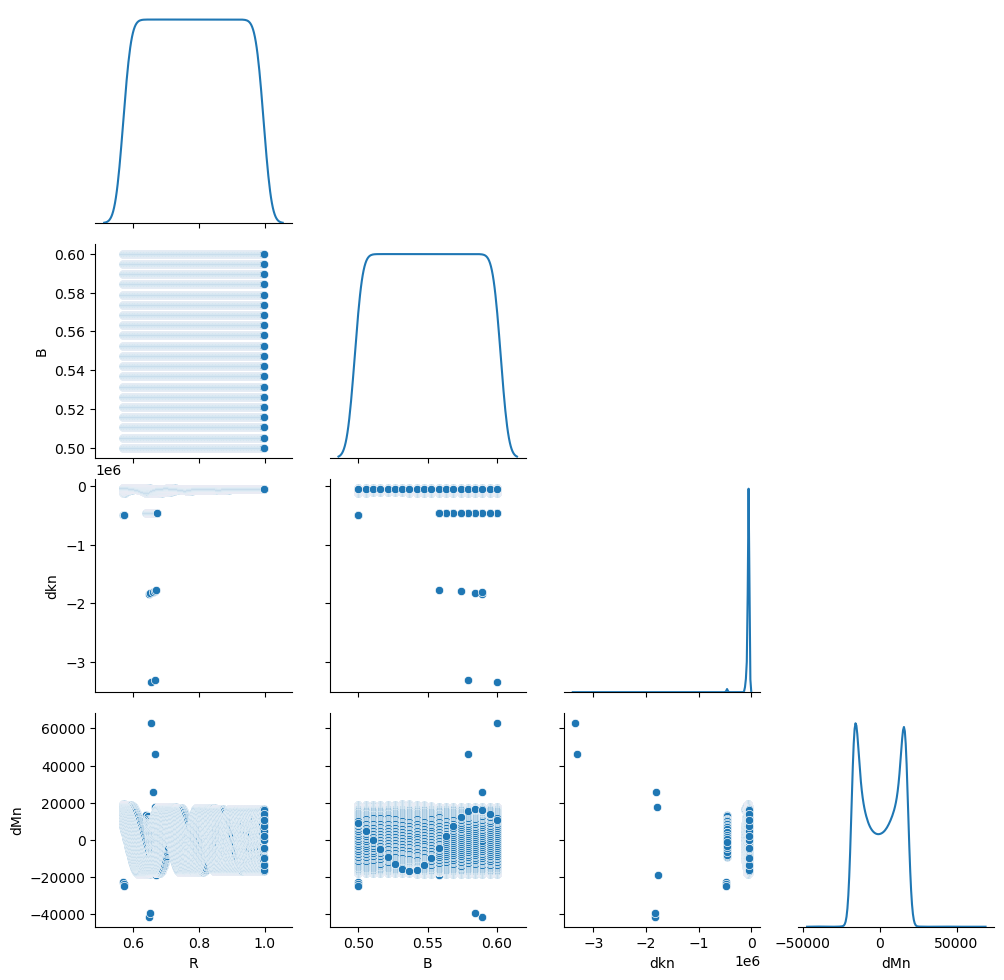

In [22]:
g = sns.PairGrid(tbl_red[0], diag_sharey=False, corner=True)

g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)

In [23]:
# I need to delete outliers again. I was hoping mu was small enough to avoid this.
tbl_red[0].loc[tbl_red[0]["dMn"] < -21000,"dMn"] = None
tbl_red[0].loc[tbl_red[0]["dMn"] > 21000,"dMn"] = None
tbl_red[0].loc[tbl_red[0]["dkn"] < -4.0e5,"dkn"] = None

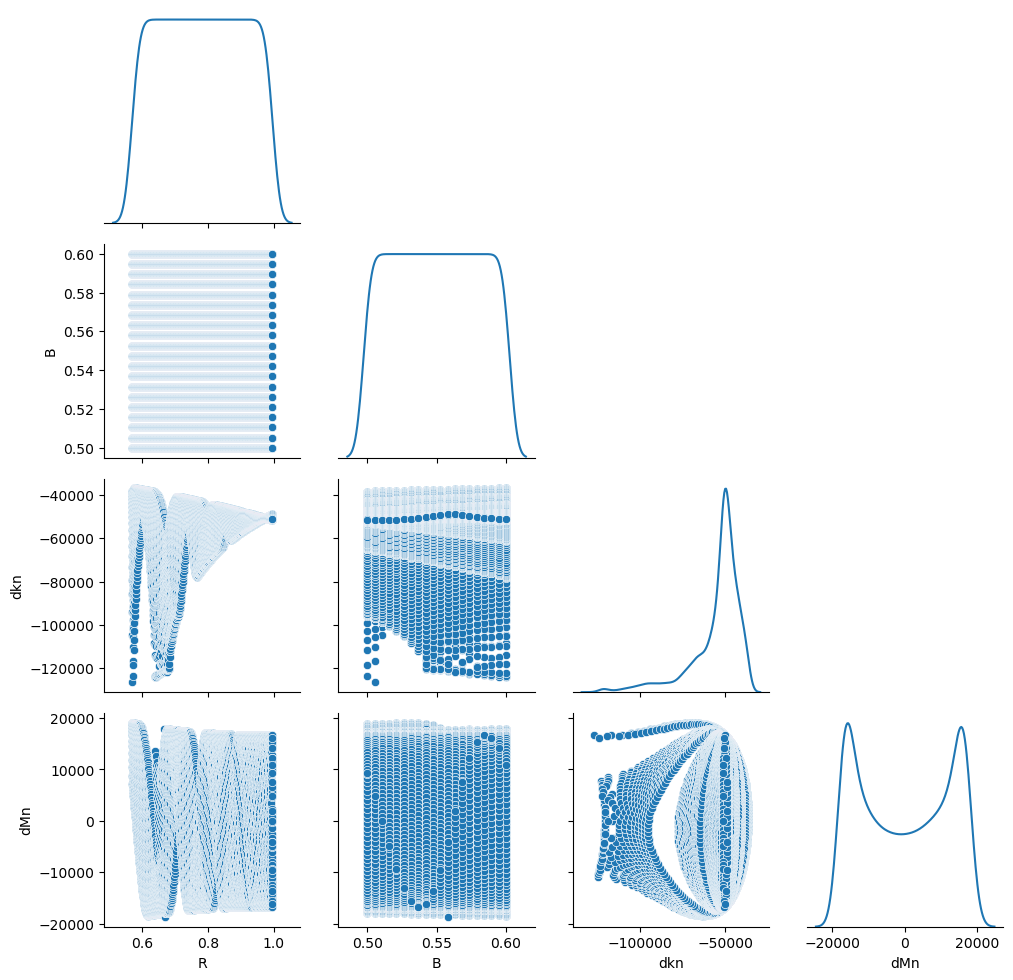

In [24]:
g = sns.PairGrid(tbl_red[0], diag_sharey=False, corner=True)

g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)

The patterns are not quite obvious here. I know that I have my small-scale (fast) oscillations fixed for this dataset, while the slow $B$ dependent oscillations should be visible. By the time I had chosen this dataset, I already know that I have one pattern based on the decimal part of $kR$ where $k$ and $R$ are in natural units, and a second pattern based on the decimal part of $\pi^2BR^2$ where $B$ and $R$ are a percent of their maximum value. The second pattern should be responsible for the oscillatory behavior visible here, while the remaining behavior is what I wish to extract from this dataset. This pattern should be found by following the envelope of these curves. There appears to be amplitude dependence on $R$. 

# Large R analysis

For my final analysis, I have fixed $R$ to always be at the same point in the small-scale oscillations with a periodicity based on $kR$, and sampled the full range of $R$ values. The large-scale $B\pi^2R^2$ oscillations should be visible in this graph, as should any unaccounted for $R$ dependent behavior. 

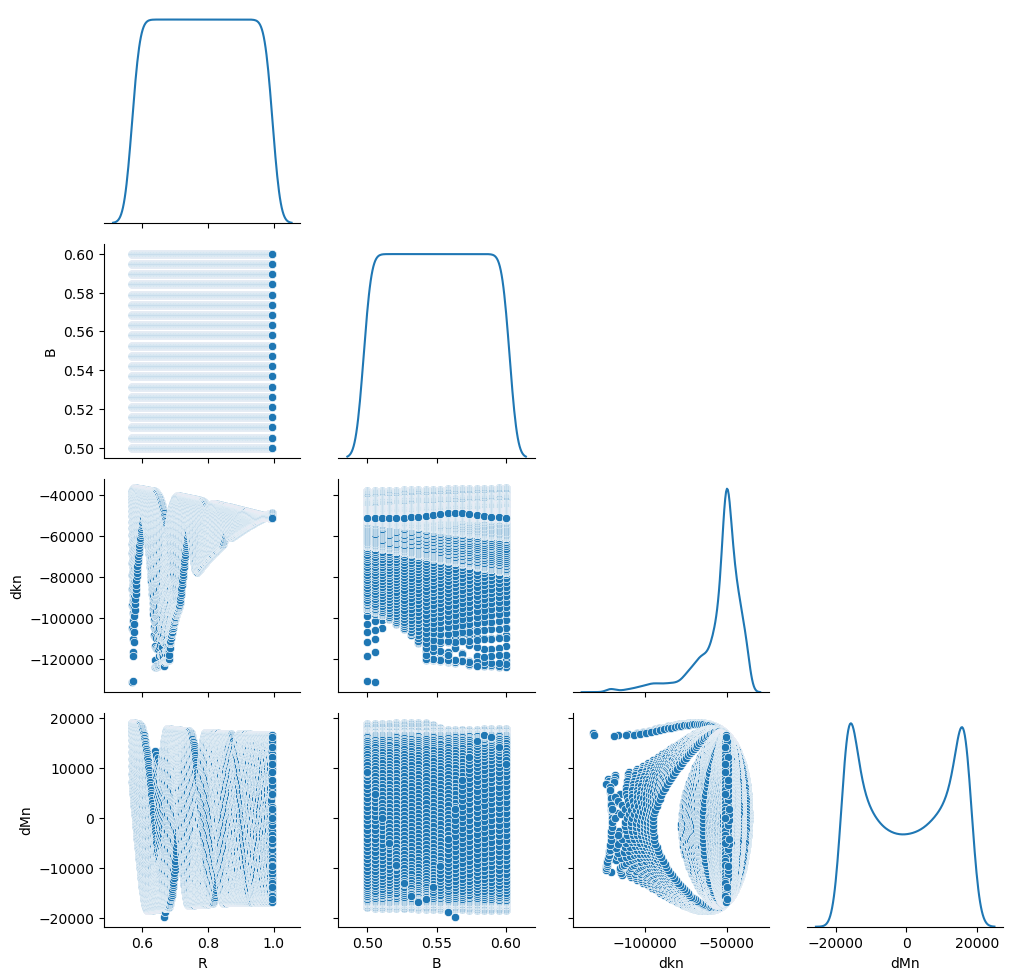

In [27]:
g = sns.PairGrid(tbl_red[0], diag_sharey=False, corner=True)

g.map_diag(sns.kdeplot)
g.map_lower(sns.scatterplot)

Lets start by loading our data.

In [25]:
gind = 0

In [26]:

dkn_arr = np.zeros((gs_r1, gs_b1))
dMn_arr = np.zeros((gs_r1, gs_b1))

for r, rr in enumerate(R_g[gind]):
    for b, bb in enumerate(B_g[gind]):
        tbl_sel = tbl_red[gind][(tbl_red[gind]["R"]==rr) &(tbl_red[gind]["B"]==bb)]
        dkn_arr[r,b] = tbl_sel["dkn"].to_numpy()[0]
        dMn_arr[r,b] = tbl_sel["dMn"].to_numpy()[0]

In [27]:
R = R_g[gind]
B = B_g[gind]

In [28]:
R[2]-R[1]

0.0008333333333333526

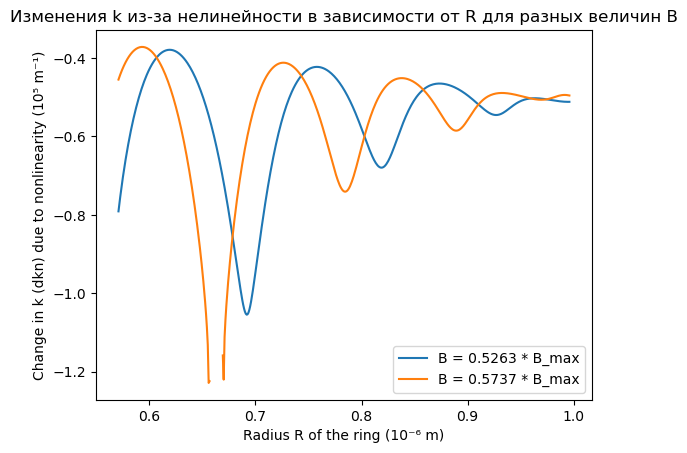

In [29]:
# Plots of dkn vs R

Bi = [5, 14]

ilim = len(Bi)

fig, ax = plt.subplots()
plt.title(f"Изменения k из-за нелинейности в зависимости от R для разных величин B")
ax.set_ylabel('Change in k (dkn) due to nonlinearity (10\u2075 m\u207b\u00b9)')
ax.set_xlabel("Radius R of the ring (10\u207b\u2076 m)")

for bb in Bi:
    ax.plot(R, dkn_arr[:,bb]/100000, label = f"B = {B[bb]:.4f} * B_max")

plt.legend()#loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()


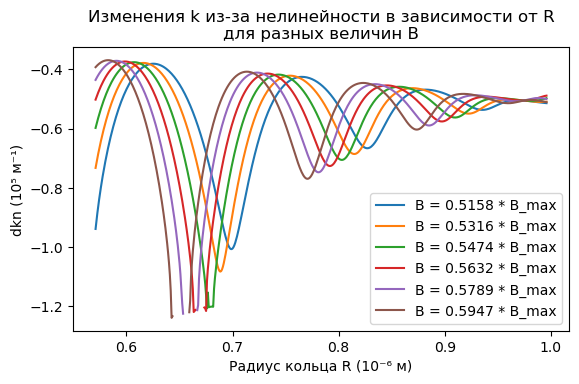

In [30]:
# Plots of dkn vs R

Bi = [3,6,9,12,15,18]

ilim = len(Bi)

fig, ax = plt.subplots()
plt.title(f"Изменения k из-за нелинейности в зависимости от R\nдля разных величин B")
ax.set_ylabel('dkn (10\u2075 м\u207b\u00b9)')
ax.set_xlabel("Радиус кольца R (10\u207b\u2076 м)")

for bb in Bi:
    ax.plot(R, dkn_arr[:,bb]/100000, label = f"B = {B[bb]:.4f} * B_max")

plt.legend()

ax.set_box_aspect(2.0/3.5)

plt.savefig("largeR3.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

The oscillations here appear to have a parabolic maximum absolute value and a linear minimum absolute value. There is a point of intersection of all the lines at a value close to $R=1$, but the exact location of that point may have to do with the choise of point on the fast oscillations. I avoided the minima, since despite the fact that it would be the most insightful, there is a problem relating to the spikes which appear only at the minima. They are either error, or a relic of the fact that we are not exactly on our $B$ node.

I now want to check that the oscillations are indeed our known $B\pi^2R^2$ oscillations.

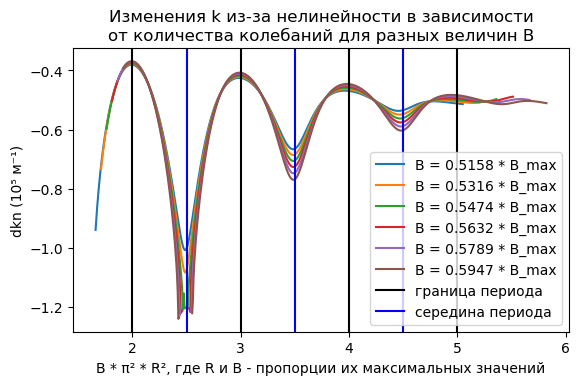

In [31]:
Bi = [3,6,9,12,15,18]

ilim = len(Bi)


fig, ax = plt.subplots()
plt.title(f"Изменения k из-за нелинейности в зависимости\nот количества колебаний для разных величин B")
ax.set_ylabel('dkn (10\u2075 м\u207b\u00b9)')
#ax.set_xlabel("Радиус кольца R (10\u207b\u2076 м)")

#plt.title(f"Change in k Due to Nonlinearity vs Number of Oscillations\nfor Various B Values")
#ax.set_ylabel('Change in k (dkn) due to nonlinearity (10\u2075 m\u207b\u00b9)')
ax.set_xlabel("B * π\u00b2 * R\u00b2, где R и B - пропорции их максимальных значений")

for bb in Bi:
    # x = B * pi^2 * R^2
    cycle_number = np.power(np.array(R), 2)*pi**2*B[bb]
    # and plot
    ax.plot(cycle_number, dkn_arr[:,bb]/100000, label = f"B = {B[bb]:.4f} * B_max")
# Count the number of cycles.
plt.axline((2,-0.6), (2,-0.66), color='k', label="граница периода")
plt.axline((2.5,-0.6), (2.5,-0.66), color='b', label = "середина периода")
plt.axline((3,-0.6), (3,-0.66), color='k')
plt.axline((3.5,-0.6), (3.5,-0.66), color='b')
plt.axline((4,-0.6), (4,-0.66), color='k')
plt.axline((4.5,-0.6), (4.5,-0.66), color='b')
plt.axline((5,-0.6), (5,-0.66), color='k')

plt.legend()

ax.set_box_aspect(2.0/3.5)

plt.savefig("largeR4.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

In [32]:
(np.sqrt(3/B[5]/pi**2)-R[0])/(R[-1]-R[0])*(len(R)-1)

226.83732475160403

In [33]:
0.01/(R[-1]-R[0])*(len(R)-1)

12.0

In [34]:
x_min = []
y_min = []
tol = 10
R_dif = (R[-1]-R[0])/(len(R)-1)
for i, ii in enumerate(B):
    for jj in range(2, 6):
        rr = np.sqrt(jj/ii/pi**2)
        ri = (rr - R[0])//R_dif
        rmni = ri - tol
        if rmni < 0: rmni = 0
        if rmni >= len(R): continue
        rmxi = ri + tol
        if rmxi >= len(R): rmxi = len(R)-1
        if rmxi <= 0: continue

        rmni = int(rmni)
        rmxi = int(rmxi)
        #print(rmni, rmxi)
        rmn = R[rmni]
        rmx = R[rmxi]
        yi = np.max(dkn_arr[rmni:rmxi,i])
        xi = np.argmax(dkn_arr[rmni:rmxi,i])
        x_min.append(R[xi + rmni])
        y_min.append(yi)

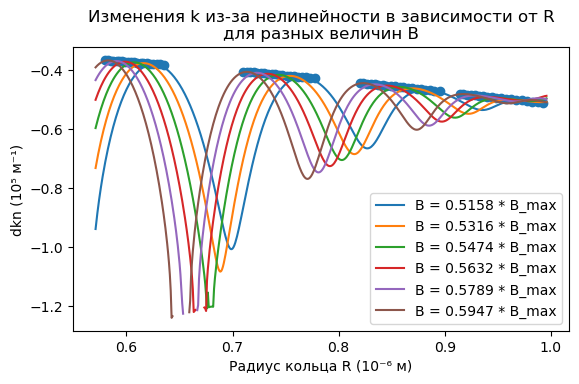

In [35]:
Bi = [3,6,9,12,15,18]

ilim = len(Bi)

fig, ax = plt.subplots()
plt.title(f"Изменения k из-за нелинейности в зависимости от R\nдля разных величин B")
ax.set_ylabel('dkn (10\u2075 м\u207b\u00b9)')
ax.set_xlabel("Радиус кольца R (10\u207b\u2076 м)")

for bb in Bi:
    ax.plot(R, dkn_arr[:,bb]/100000, label = f"B = {B[bb]:.4f} * B_max")

ax.scatter(x_min, np.array(y_min)/100000)


plt.legend()

ax.set_box_aspect(2.0/3.5)

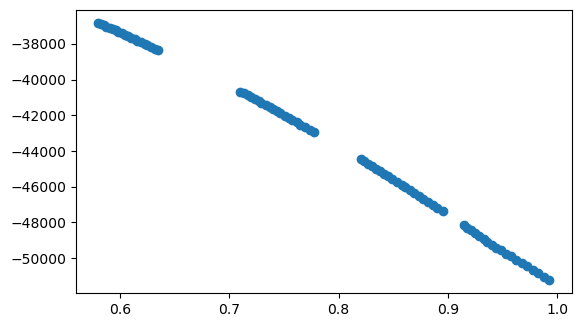

In [36]:
# Plots of dkn vs R

fig, ax = plt.subplots()
#plt.title(f"Изменения k из-за нелинейности в зависимости от R\nдля разных величин B")
#ax.set_ylabel('dkn (10\u2075 м\u207b\u00b9)')
#ax.set_xlabel("Радиус кольца R (10\u207b\u2076 м)")

ax.scatter(x_min, y_min)

ax.set_box_aspect(2.0/3.5)

plt.show()

In [38]:
labels = [('x', float), ('y', float)]
values = [(x_min[i], y_min[i]) for i in range(len(x_min))]
arr = np.array(values, dtype=labels)       # create a structured array
arr = np.sort(arr, order='x')   
x_d = []
y_d = []
for av in arr:
    #print(av)
    x_d.append(av[0])
    y_d.append(av[1])

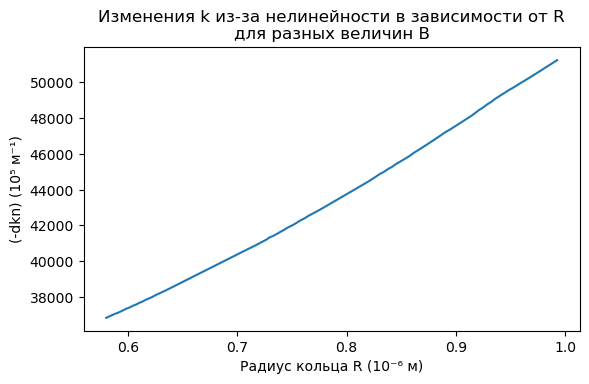

In [39]:
# Plots of dkn vs R

fig, ax = plt.subplots()
plt.title(f"Изменения k из-за нелинейности в зависимости от R\nдля разных величин B")
ax.set_ylabel('(-dkn) (10\u2075 м\u207b\u00b9)')
ax.set_xlabel("Радиус кольца R (10\u207b\u2076 м)")

ax.plot(x_d, (-np.array(y_d)))

ax.set_box_aspect(2.0/3.5)

plt.show()

In [40]:
# Regression

r = 1.1    # for finding the minimum r value

X = np.array(x_min) # Power laws are straight lines on log-log plots.
X=X.reshape(-1, 1)
y = np.abs(y_min) # Power laws are straight lines on log-log plots.

reg = LinearRegression().fit(X, y)

slope_min1=reg.coef_[0]
intercept_min1=reg.intercept_

r = reg.score(X, y)

print("For the linear regression of abs(-I_min) vs (\u03BC)")
print(f"Fitted slope of \u03BC:      {slope_min1}")
print(f"Intercept of \u03BC: {intercept_min1}")
print("Convergence Statistic:  ", r) 

For the linear regression of abs(-I_min) vs (μ)
Fitted slope of μ:      34984.32088210607
Intercept of μ: 16089.896671113118
Convergence Statistic:   0.996343665464356


In [41]:
# Regression

r = 1.1    # for finding the minimum r value

X = np.array([np.array(x_min), np.power(x_min, 2)]) # Power laws are straight lines on log-log plots.
X=X.T
y = np.abs(y_min) # Power laws are straight lines on log-log plots.

reg = LinearRegression().fit(X, y)

slope_min3=reg.coef_
intercept_min3=reg.intercept_

r = reg.score(X, y)

print("For the linear regression of abs(-I_min) vs (\u03BC)")
print(f"Fitted slope of \u03BC:      {slope_min3}")
print(f"Intercept of \u03BC: {intercept_min3}")
print("Convergence Statistic:  ", r) 

For the linear regression of abs(-I_min) vs (μ)
Fitted slope of μ:      [ 5050.23410506 19256.3333064 ]
Intercept of μ: 27397.069707306156
Convergence Statistic:   0.9999267619797783


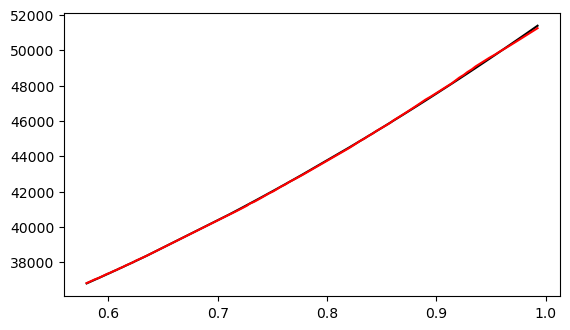

In [42]:
fig, ax = plt.subplots()
#plt.title(f"Изменения k из-за нелинейности в зависимости от R\nдля разных величин B")
#ax.set_ylabel('dkn (10\u2075 м\u207b\u00b9)')
#ax.set_xlabel("Радиус кольца R (10\u207b\u2076 м)")
x_d = np.array(x_d)
y_d = np.array(y_d)
#ax.plot(x_d, slope_min1*x_d+intercept_min1)
#ax.plot(x_d, np.power(x_d, slope_min2)*np.exp(intercept_min2))
#ax.plot(x_d, np.exp(slope_min0*x_d +intercept_min0), color = "green")
ax.plot(x_d, slope_min3[0]*x_d + slope_min3[1]*np.power(x_d,2)+intercept_min3, color = "black")
ax.plot(x_d, -y_d, color = "red")

ax.set_box_aspect(2.0/3.5)

plt.show()

In [43]:
x_d_min = np.array(x_d)
y_d_min = np.array(y_d)
y_p_min = slope_min3[0]*x_d + slope_min3[1]*np.power(x_d,2)+intercept_min3

In [44]:
x_max = []
y_max = []
tol = 10
R_dif = (R[-1]-R[0])/(len(R)-1)
for i, ii in enumerate(B):
    for jj in range(2, 5):
        if jj == 2 and i > 6: continue
        rr = np.sqrt((jj+.5)/ii/pi**2)
        ri = (rr - R[0])//R_dif
        rmni = ri - tol
        if rmni < 0: rmni = 0
        if rmni >= len(R): continue
        rmxi = ri + tol
        if rmxi >= len(R): rmxi = len(R)-1
        if rmxi <= 0: continue

        rmni = int(rmni)
        rmxi = int(rmxi)
        #print(rmni, rmxi)
        rmn = R[rmni]
        rmx = R[rmxi]
        yi = np.min(dkn_arr[rmni:rmxi,i])
        xi = np.argmin(dkn_arr[rmni:rmxi,i])
        x_max.append(R[xi + rmni])
        y_max.append(yi)

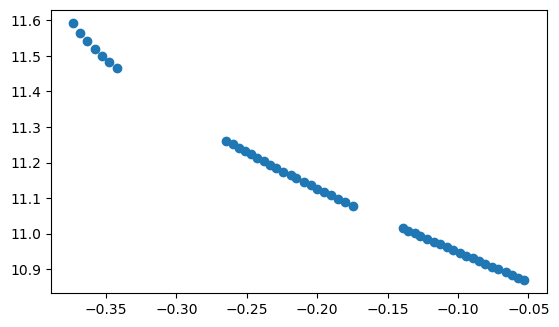

In [45]:
# Plots of dkn vs R

fig, ax = plt.subplots()
#plt.title(f"Изменения k из-за нелинейности в зависимости от R\nдля разных величин B")
#ax.set_ylabel('dkn (10\u2075 м\u207b\u00b9)')
#ax.set_xlabel("Радиус кольца R (10\u207b\u2076 м)")

ax.scatter(np.log(x_max), np.log(np.abs(y_max)))

ax.set_box_aspect(2.0/3.5)

plt.show()

In [46]:
# Regression

r = 1.1    # for finding the minimum r value

#X = np.array([np.array(x_max), np.arctan(x_max), np.power(np.arcsin(x_max), -1)]) # Power laws are straight lines on log-log plots.
#X = np.array([np.array(x_max), np.power(x_max,2), np.power(np.array(x_max), 3), np.power(np.array(x_max), 4)]) # Power laws are straight lines on log-log plots.
X = np.array([np.array(x_max), np.power(x_max,2), np.power(x_max,3)]) # Power laws are straight lines on log-log plots.

X=X.T
y = 1/np.array(np.abs(y_max)) # Power laws are straight lines on log-log plots.

reg = LinearRegression().fit(X, y)

slope_max3=reg.coef_
intercept_max3=reg.intercept_

r = reg.score(X, y)

print("For the linear regression of ln(-I_min) vs ln(\u03BC)")
print(f"slopes \u03BC:      {slope_max3}")
print(f"intercept \u03BC: {intercept_max3}")
print("Convergence Statistic:  ", r) 

For the linear regression of ln(-I_min) vs ln(μ)
slopes μ:      [ 0.00041142 -0.00043116  0.00016367]
intercept μ: -0.00012292977259216318
Convergence Statistic:   0.9998803172893417


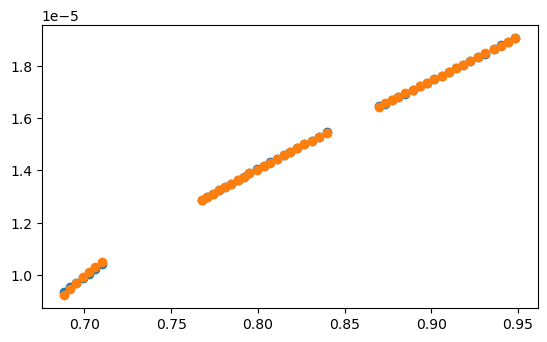

In [48]:
# Plots of dkn vs R

fig, ax = plt.subplots()
#plt.title(f"Изменения k из-за нелинейности в зависимости от R\nдля разных величин B")
#ax.set_ylabel('dkn (10\u2075 м\u207b\u00b9)')
#ax.set_xlabel("Радиус кольца R (10\u207b\u2076 м)")

ax.scatter(x_max, intercept_max3 + slope_max3[0]*np.array(x_max)+slope_max3[1]*np.square(x_max)+slope_max3[2]*np.power(x_max,3))
ax.scatter(x_max, -1/np.array(y_max))


ax.set_box_aspect(2.0/3.5)

plt.show()

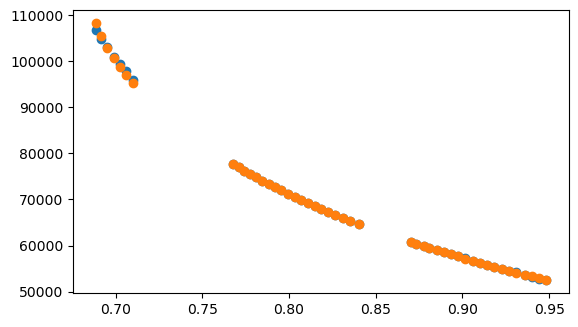

In [49]:
# Plots of dkn vs R

fig, ax = plt.subplots()
#plt.title(f"Изменения k из-за нелинейности в зависимости от R\nдля разных величин B")
#ax.set_ylabel('dkn (10\u2075 м\u207b\u00b9)')
#ax.set_xlabel("Радиус кольца R (10\u207b\u2076 м)")

ax.scatter(x_max, 1/(intercept_max3 + slope_max3[0]*np.array(x_max)+slope_max3[1]*np.square(x_max)+slope_max3[2]*np.power(x_max, 3)))
ax.scatter(x_max, -np.array(y_max))


ax.set_box_aspect(2.0/3.5)

plt.show()

In [50]:
labels = [('x', float), ('y', float)]
values = [(x_max[i], y_max[i]) for i in range(len(x_max))]
arr = np.array(values, dtype=labels)       # create a structured array
arr = np.sort(arr, order='x')   
x_d = []
y_d = []
for av in arr:
    #print(av)
    x_d.append(av[0])
    y_d.append(av[1])

In [51]:
x_lin = np.linspace(0.668, x_d_min[-1],200)

In [52]:
x_d_max = np.array(x_d)
y_d_max = np.array(y_d)
y_p_max = 1/(intercept_max3+slope_max3[0]*np.power(x_d_max,1)+slope_max3[1]*np.power(x_d_max, 2)+slope_max3[2]*np.power(x_d_max, 3))
y_p_max_2 = 1/(intercept_max3+slope_max3[0]*np.power(x_lin,1)+slope_max3[1]*np.power(x_lin, 2)+slope_max3[2]*np.power(x_lin, 3))

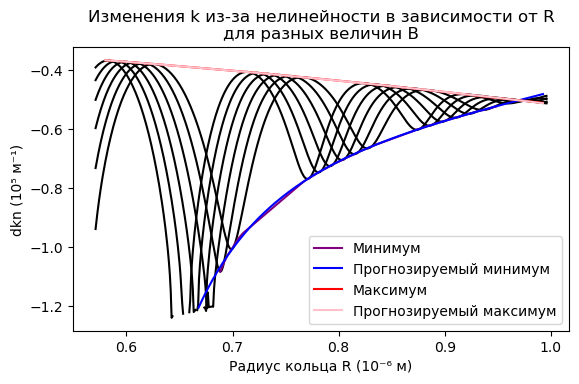

In [53]:
# Plots of dkn vs R
Bi = [3,6,9,12,15,18]

ilim = len(Bi)


fig, ax = plt.subplots()
plt.title(f"Изменения k из-за нелинейности в зависимости от R\nдля разных величин B")
ax.set_ylabel('dkn (10\u2075 м\u207b\u00b9)')
ax.set_xlabel("Радиус кольца R (10\u207b\u2076 м)")

for bb in Bi:
    ax.plot(R, dkn_arr[:,bb]/100000, color = "black")

ax.plot(x_d_max, -np.abs(y_d_max)/100000, color = "purple", label = "Минимум")
ax.plot(x_lin, -np.abs(y_p_max_2)/100000, color = "blue", label = "Прогнозируемый минимум")
#ax.plot(x_d_max, -y_p_max/100000)
ax.plot(x_d_min, -np.abs(y_d_min)/100000, color = "red", label = "Максимум")
ax.plot(x_d_min, -y_p_min/100000, color = "pink", label = "Прогнозируемый максимум")

ax.set_box_aspect(2.0/3.5)
plt.legend()

plt.savefig("Rmodel1.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

In [ ]:
Bi = [3,6,9,12,15,18]

ilim = len(Bi)

fig, ax = plt.subplots()
plt.title(f"Изменения k из-за нелинейности в зависимости от R\nдля разных величин B")
ax.set_ylabel('dkn (10\u2075 м\u207b\u00b9)')
ax.set_xlabel("Радиус кольца R (10\u207b\u2076 м)")

for bb in Bi:
    ax.plot(R, dkn_arr[:,bb]/100000, label = f"B = {B[bb]:.4f} * B_max")

ax.scatter(x_min, np.array(y_min)/100000)


plt.legend()

ax.set_box_aspect(2.0/3.5)

The minima are close to or on the cycle boundary, while the maxima are close to or on the half period. The period is definitely correct. There may be a slight translation, but that could actually be expected from our skewed secant squared function fit.